# Анализ рынка недвижимости и прогнозирование цен

**Цель проекта:** Исследовать геометрические параметры домов (`dim_1`, `dim_2`), провести кластеризацию объектов, настроить классификатор уровней комфорта и построить регрессионную модель для оценки стоимости недвижимости.

## 1. Загрузка данных и первичный анализ
Импортируем необходимые библиотеки и загрузим наш основной датасет.


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Настраиваем шрифты для графиков
plt.rc("font", size=14)

# Загружаем данные
houses = pd.read_csv("../data/1.4_houses.csv")

# Выводим первые 5 строк датасета, чтобы убедиться в успешной загрузке
houses.head()

,dim_1,dim_2,level,price
0,29,28,luxury,2212.0
1,28,29,luxury,2203.0
2,6,9,basic,254.0
3,5,9,basic,242.0
4,6,6,basic,195.0


## 2. Разведочный анализ данных (EDA) и разделение выборки
*Здесь мы изучим распределение данных и подготовим их к обучению моделей.*

In [7]:
# Посмотрим на типы данных и общую информацию о датасете
print("--- Информация о датасете ---")
houses.info()

# Проверим наличие пропущенных значений в каждой колонке
print("\n--- Проверка на пропущенные значения ---")
print(houses.isna().sum())

# Выведем основные статистические метрики для числовых признаков
print("\n--- Статистическое описание числовых признаков ---")
houses.describe()

--- Информация о датасете ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dim_1   100 non-null    int64  
 1   dim_2   100 non-null    int64  
 2   level   100 non-null    str    
 3   price   100 non-null    float64
dtypes: float64(1), int64(2), str(1)
memory usage: 3.8 KB

--- Проверка на пропущенные значения ---
dim_1    0
dim_2    0
level    0
price    0
dtype: int64

--- Статистическое описание числовых признаков ---


,dim_1,dim_2,price
count,100.000000,100.000000,100.000000
mean,16.400000,16.110000,1010.970000
std,9.340906,9.105326,801.572879
min,5.000000,5.000000,150.000000
25%,7.000000,7.000000,244.250000
50%,17.000000,14.000000,808.000000
75%,27.000000,27.000000,1992.500000
max,29.000000,29.000000,2285.000000


## 3. Разделение данных и обучение моделей

Чтобы объективно оценить качество работы наших моделей, мы разделим данные на две части:
* **Обучающая выборка (Train)** — 80% данных для настройки моделей.
* **Тестовая выборка (Test)** — 20% данных, которые модель не видела, для финальной проверки.

Начнем с задачи **Классификации** (предсказание категориальной целевой переменной `level` по признакам `dim_1` и `dim_2`).

In [8]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# 1. Выделяем признаки и целевую переменную
X_clf = houses[["dim_1", "dim_2"]]
y_clf = houses["level"]

# 2. Разделяем на train и test выборки
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# 3. Создаем и обучаем классификатор на тренировочных данных
cl = DecisionTreeClassifier().fit(X_train_clf, y_train_clf)

# 4. Делаем предсказание на тестовых данных, которые модель еще не видела
y_pred_clf = cl.predict(X_test_clf)

# 5. Выводим метрики качества (Precision, Recall, F1-score)
print("--- Отчет о качестве классификации (Тестовая выборка) ---")
print(classification_report(y_test_clf, y_pred_clf))

--- Отчет о качестве классификации (Тестовая выборка) ---
              precision    recall  f1-score   support

       basic       1.00      1.00      1.00        10
      luxury       1.00      1.00      1.00         6
      medium       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 4. Задача регрессии: Прогнозирование стоимости недвижимости

Построим множественную линейную регрессию (`LinearRegression`) для предсказания стоимости дома (`price`) на основе двух геометрических параметров (`dim_1`, `dim_2`).

Для валидации модели разделим данные на обучающую (80%) и тестовую (20%) выборки. Качество оценим с помощью метрик $R^2$ (коэффициент детерминации) и $MSE$ (среднеквадратичная ошибка).

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Выделяем признаки и таргет
X_reg = houses[["dim_1", "dim_2"]]
y_reg = houses["price"]

# 2. Разделяем выборку на train/test (80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Обучаем модель регрессии
reg = LinearRegression().fit(X_train_reg, y_train_reg)

# 4. Делаем предсказание на тестовой выборке
y_pred_reg = reg.predict(X_test_reg)

# 5. Рассчитываем метрики качества
r2 = r2_score(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)

print("=== Метрики качества регрессии (Тестовая выборка) ===")
print(f"Коэффициент детерминации (R² Score): {r2:.4f}")
print(f"Среднеквадратичная ошибка (MSE): {mse:.2f}")
print(f"Интерцепт (a): {reg.intercept_:.2f}")
print(f"Коэффициенты (b1, b2): {reg.coef_}")

=== Метрики качества регрессии (Тестовая выборка) ===
Коэффициент детерминации (R² Score): 0.9856
Среднеквадратичная ошибка (MSE): 9548.44
Интерцепт (a): -424.98
Коэффициенты (b1, b2): [34.55664839 53.44244472]


### Визуализация плоскости регрессии в 3D
Построим трёхмерный график, отображающий реальные точки тестовой выборки и непрерывную плоскость предсказаний нашей модели. Для исключения предупреждений о названиях признаков, координатную сетку сформируем в виде Pandas DataFrame.

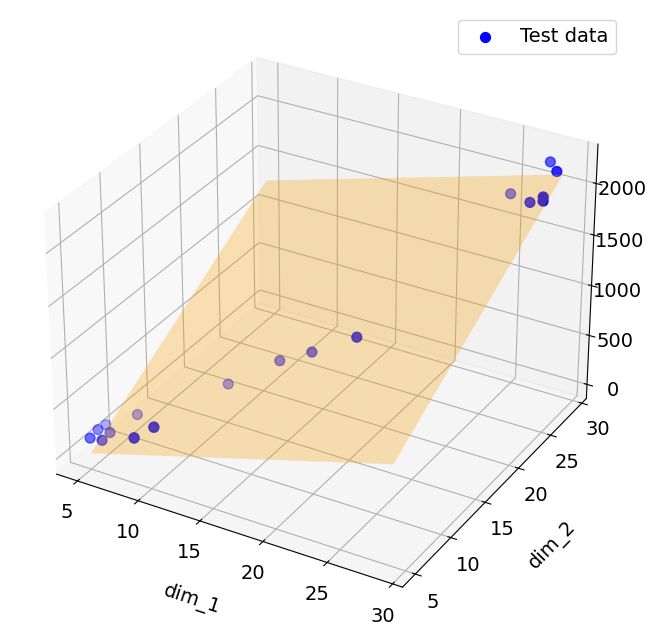

In [10]:
# Создаем сетку значений для построения плоскости
x_coord = np.linspace(X_reg["dim_1"].min(), X_reg["dim_1"].max(), 100)
y_coord = np.linspace(X_reg["dim_2"].min(), X_reg["dim_2"].max(), 100)

d1, d2 = list(), list()
for x in x_coord:
    for y in y_coord:
        d1.append(x)
        d2.append(y)

d1 = np.array(d1).reshape(-1, 1)
d2 = np.array(d2).reshape(-1, 1)

# Формируем DataFrame с валидными именами колонок для predict
grid_df = pd.DataFrame(np.concatenate([d1, d2], axis=1), columns=["dim_1", "dim_2"])
p = reg.predict(grid_df)

# Инициализируем 3D график
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection="3d")

# Отображаем только тестовые точки для оценки качества на валидации
ax.scatter(X_test_reg["dim_1"], X_test_reg["dim_2"], y_test_reg, c="blue", s=50, label="Test data")

# Отрисовываем плоскость предсказаний
ax.plot_trisurf(d1.ravel(), d2.ravel(), p.ravel(), color="orange", alpha=0.3)

# Настраиваем оси и отодвигаем подписи (labelpad=15 сдвинет текст дальше от цифр)
ax.set_xlabel("dim_1", labelpad=15)
ax.set_ylabel("dim_2", labelpad=15)
ax.set_zlabel("price", labelpad=15)
ax.legend()

plt.savefig("../output/regression_3d_visual.png", bbox_inches="tight", dpi=300)
# Отображаем график в ноутбуке
plt.show()

## 5. Сегментация рынка недвижимости (Кластеризация)

Используем алгоритм ненаправленного обучения **KMeans** для разделения всех объектов недвижимости на 5 обособленных кластеров на основе их геометрических признаков (`dim_1`, `dim_2`). Это позволит выявить скрытые структуры в данных без использования готовых меток классов.

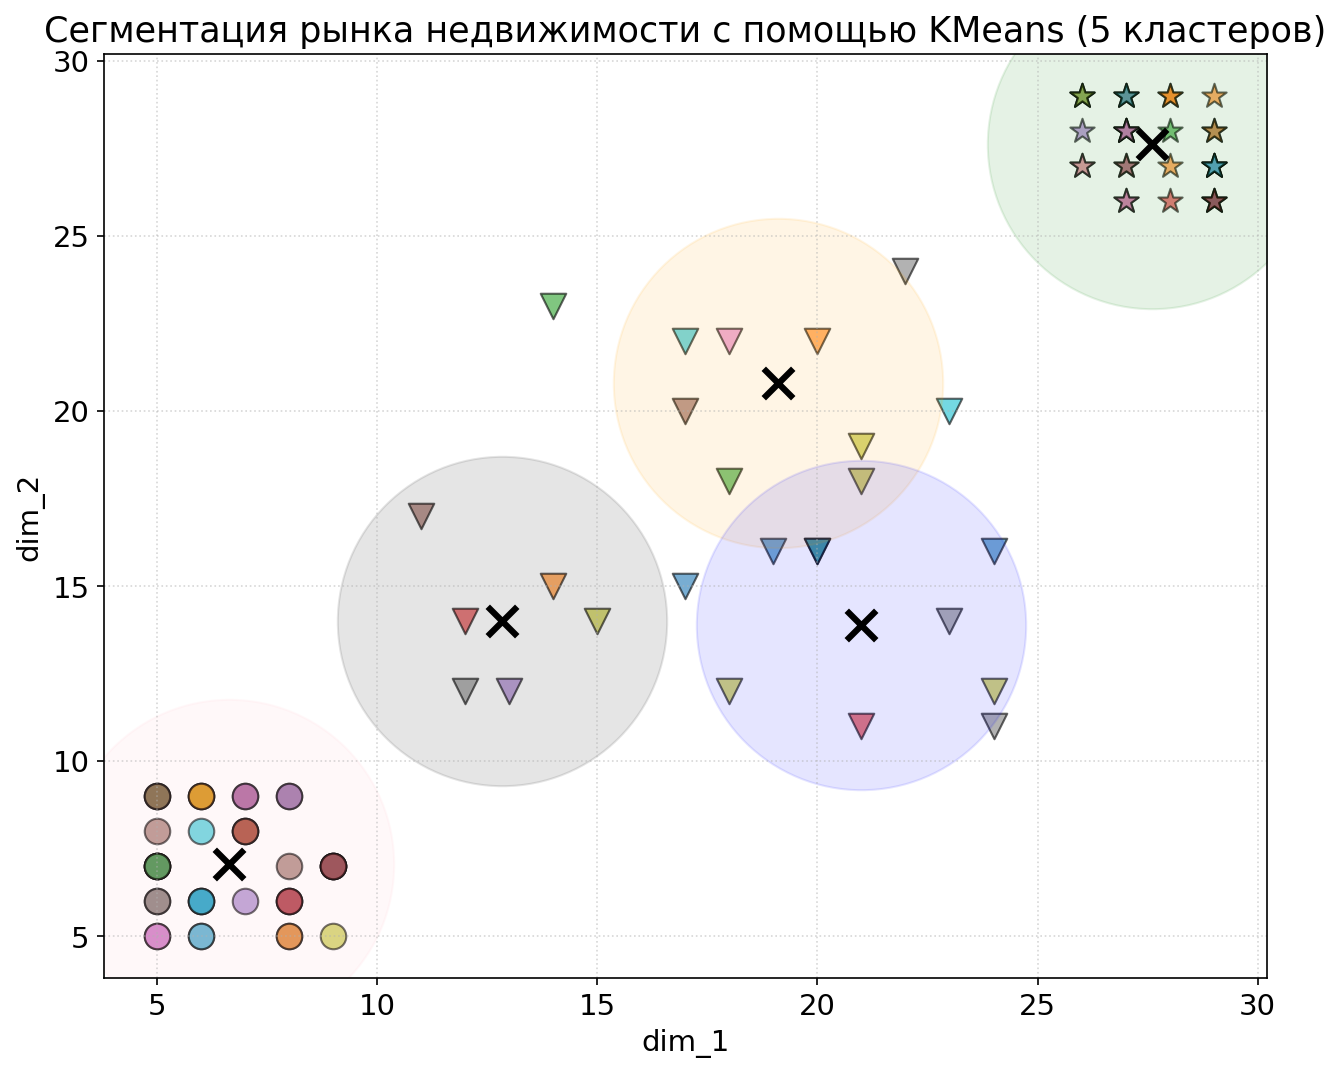

In [11]:
# 1. Для кластеризации берем только признаки (таргет не нужен)
X_clust = houses[["dim_1", "dim_2"]]

# 2. Инициализируем и обучаем KMeans на 5 кластеров
clust = KMeans(n_clusters=5, random_state=42).fit(X_clust)

# 3. Извлекаем координаты центров полученных кластеров
centers = clust.cluster_centers_

# 4. Строим двумерный график распределения объектов
plt.figure(figsize=(10, 8), dpi=150)

# Словарь маркеров для отображения реальных типов комфорта из исходных данных
markers = {"basic": "o", "medium": "v", "luxury": "*"}

# Отрисовываем дома, подсвечивая их реальный уровень комфорта маркерами
for d1, d2, l in zip(houses["dim_1"], houses["dim_2"], houses["level"]):
    plt.scatter(d1, d2, s=150, marker=markers[l], alpha=0.6, edgecolors="black")

# Наносим центроиды кластеров (черные крестики) и области их влияния
colors = ["black", "green", "orange", "blue", "pink"]
for i, center in enumerate(centers):
    plt.scatter(center[0], center[1], s=200, marker="x", c="black", linewidths=3, zorder=5)
    plt.scatter(center[0], center[1], s=25000, c=colors[i], alpha=0.1, zorder=1)

plt.xlabel("dim_1")
plt.ylabel("dim_2")
plt.title("Сегментация рынка недвижимости с помощью KMeans (5 кластеров)")
plt.grid(True, linestyle=":", alpha=0.5)

plt.savefig("../output/clusters_visual.png", bbox_inches="tight", dpi=300)
# 5. Отображаем график в самом ноутбуке
plt.show()

## Заключение и выводы проекта
В ходе работы над проектом были успешно решены три ключевые аналитические задачи:
1. **Классификация:** Построено дерево решений, способное распределять дома по уровням комфорта на основе геометрии.
2. **Регрессия:** Построена 3D-плоскость линейной регрессии, показавшая отличную точность ($R^2 = 0.9856$) при прогнозировании рыночной стоимости.
3. **Кластеризацию:** Алгоритм KMeans успешно сегментировал рынок на 5 различных групп объектов, что подтверждается визуализацией центроидов.